In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

/var/folders/t5/r7v7vh5j4f3f7r2g49vwg_780000gn/T/ipykernel_89961/3514654702.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader, DirectoryLoader


In [3]:
load_dotenv()

True

In [4]:
llm = ChatOpenAI(
    model    = "gpt-5-mini",  
    api_key  = os.getenv("AZURE_OPENAI_API_KEY"),
    base_url = os.getenv("AZURE_OPENAI_ENDPOINT")
)


In [5]:
# Embeddings
embedder = OpenAIEmbeddings(
    model="text-embedding-3-small",  
    dimensions=1024,
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    base_url=os.getenv("AZURE_OPENAI_ENDPOINT"),
)

In [6]:
# Load Document
OUT_DIR = Path("./Clean_Transcript/")

# Return inn string format so as_posix()
loader = DirectoryLoader(OUT_DIR.as_posix(),
                            loader_cls = TextLoader,
                            show_progress=True)

In [7]:
docs = loader.load()

100%|██████████| 14/14 [00:00<00:00, 1058.54it/s]


In [8]:
# Split text
chunker = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap = 50)
chunk = chunker.split_documents(docs)

In [10]:
vector_store = Chroma(collection_name="rag_demo",
                      embedding_function = embedder,
                      persist_directory = Path("./saved-embeddings").as_posix())

In [61]:
# add docs
vector_store.add_documents(chunk)

['ee8f6b68-eac8-4b75-acee-556d2cedaf18',
 '580e362a-bcaa-4e8c-94f8-b7a8b93a388d',
 '720dffb8-655f-451c-85bf-792a59dac4b6',
 'e9f041dd-5394-493d-b2c9-929758ad9b96',
 '6f001050-1c27-468b-acfd-bffd134a5886',
 '82ac1558-a314-4348-9647-3be4013179e2',
 'c153b4df-289e-4689-9967-0997e7381c62',
 'b8b478e6-3d03-4786-8290-a0f97c33c42f',
 'dc2dd99f-e270-412e-a5cd-debab6f6cd3b',
 '24b29715-ceff-4df8-8617-1e0c07305561',
 '5ff8547a-6cd1-4cfc-ac2e-23445cae5387',
 'b5b72ccc-d5a2-4624-bedd-ac67c15fbfbb',
 '4baf90f5-6575-498a-be31-f95cc3310dfc',
 '6c2f31f3-5c37-47bd-9b3c-ce6211be3dc0',
 'b54300a5-e163-419d-80d0-e5f3897dbada',
 '3527e9d3-f35c-4423-b411-46b42293193f',
 '38c5bd77-cf8a-42e3-bad3-4b34dd1e8929',
 'fca98a41-7f29-4995-ae68-357c2ed273dc',
 '7bb12852-e3ea-4ae3-b96f-4df590cbe7dc',
 'a3c5c690-e7d7-4bfa-a79e-bc8335dc19ad',
 '8ead12ca-4a43-43ab-ba7a-ab741abe7b1f',
 'cbd76201-b845-4b1a-8466-877d63d5eacb',
 'e2e8c573-1ad9-4487-b987-f9e46c6a46e5',
 '1e2f8db9-747d-4aae-a8ce-5916fe8ecabf',
 'f9da0871-0080-

In [11]:
retriever = vector_store.as_retriever(search_kwargs={"k":3})

In [12]:
from langgraph.graph import StateGraph, START, END 
from typing import Literal, TypedDict

In [13]:
class RAGState(TypedDict):
    query: str 
    response : str 
    retrieved_docs : list[Document]
    context : str
    prompt : ChatPromptTemplate

In [14]:

from langchain_core.output_parsers import StrOutputParser

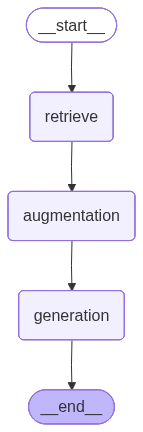

In [15]:
graph = StateGraph(RAGState)

def retrieve(state:RAGState):
    query = state["query"]
    retrieved_docs = retriever.invoke(query)
    context = "\n".join([doc.page_content for doc in retrieved_docs])
    return {"retrieved_docs" : retrieved_docs,
           "context" : context
           }

def augmentation(state:RAGState):
    query = state["query"]
    context = state["context"]
    prompt = ChatPromptTemplate.from_messages([
        ("system", (
            "You are a helpful RAG assistant. "
            "Answer the user query based on context only. "
            "If you do not know the answer, say you do not know."
        )),
        ("human", "context: {context}\n\nquery: {query}")
    ])


    
    return {"prompt":prompt}

def generation(state:RAGState):
    context   = state["context"]
    query     = state["query"]
    prompt    = state["prompt"]
    llm_chain = prompt | llm | StrOutputParser()
    response  = llm_chain.invoke({"context":context, "query":query})
    return {"response":response}
    

graph.add_node("retrieve",retrieve)
graph.add_node("augmentation",augmentation)
graph.add_node("generation",generation)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve","augmentation")
graph.add_edge("augmentation","generation")
graph.add_edge("generation",END)

workflow = graph.compile()

workflow

In [16]:
result = workflow.invoke({"query" : "What is LLM Eval"})


In [17]:
result["response"]

'An LLM Eval is a set of systematic, repeatable tests used to measure whether an LLM or an LLM-based application is performing well against clear criteria. In other words, evals are tests (not just a single metric) that tell you if the model is doing a good job, if it’s ready to launch, and if users can use it reliably. Key characteristics: repeatable, systematic, and tied to explicit evaluation criteria.'